In [10]:
%pip install pandas numpy matplotlib scikit-learn openpyxl seaborn

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Removed 10 rows (Patient 6 / CSV3)
Volume range: [0.00, 454.90]
Samples per patient:
Patient.ID
5    30
6    20
7    30
8    30
dtype: int64

Extracting features...
Total raw records : 110
Base features/part: 336

  Approach: Calibration-Assisted  (5-Fold CV)

  Model                     RMSE       MAE        R²
  Random Forest            34.74     20.58     0.885
  Gradient Boosting        41.04     18.65     0.840
  SVR (RBF)                44.35     37.66     0.813
  Ridge (α=0.1)            87.32     48.75     0.275
  Ridge (α=1)              62.25     38.09     0.631
  Ridge (α=10)             61.68     35.69     0.638

  Approach: Baseline-Normalised  (5-Fold CV)

  Model                     RMSE       MAE        R²
  Random Forest            29.71     16.87     0.916
  Gradient Boosting        28.80     14.93     0.921
  SVR (RBF)                43.12     36.73     0.823
  Ridge (α=0.1)            50.44     30.28     0.758
  Ridge (α=1)              47.20     26.99     0.788
  R

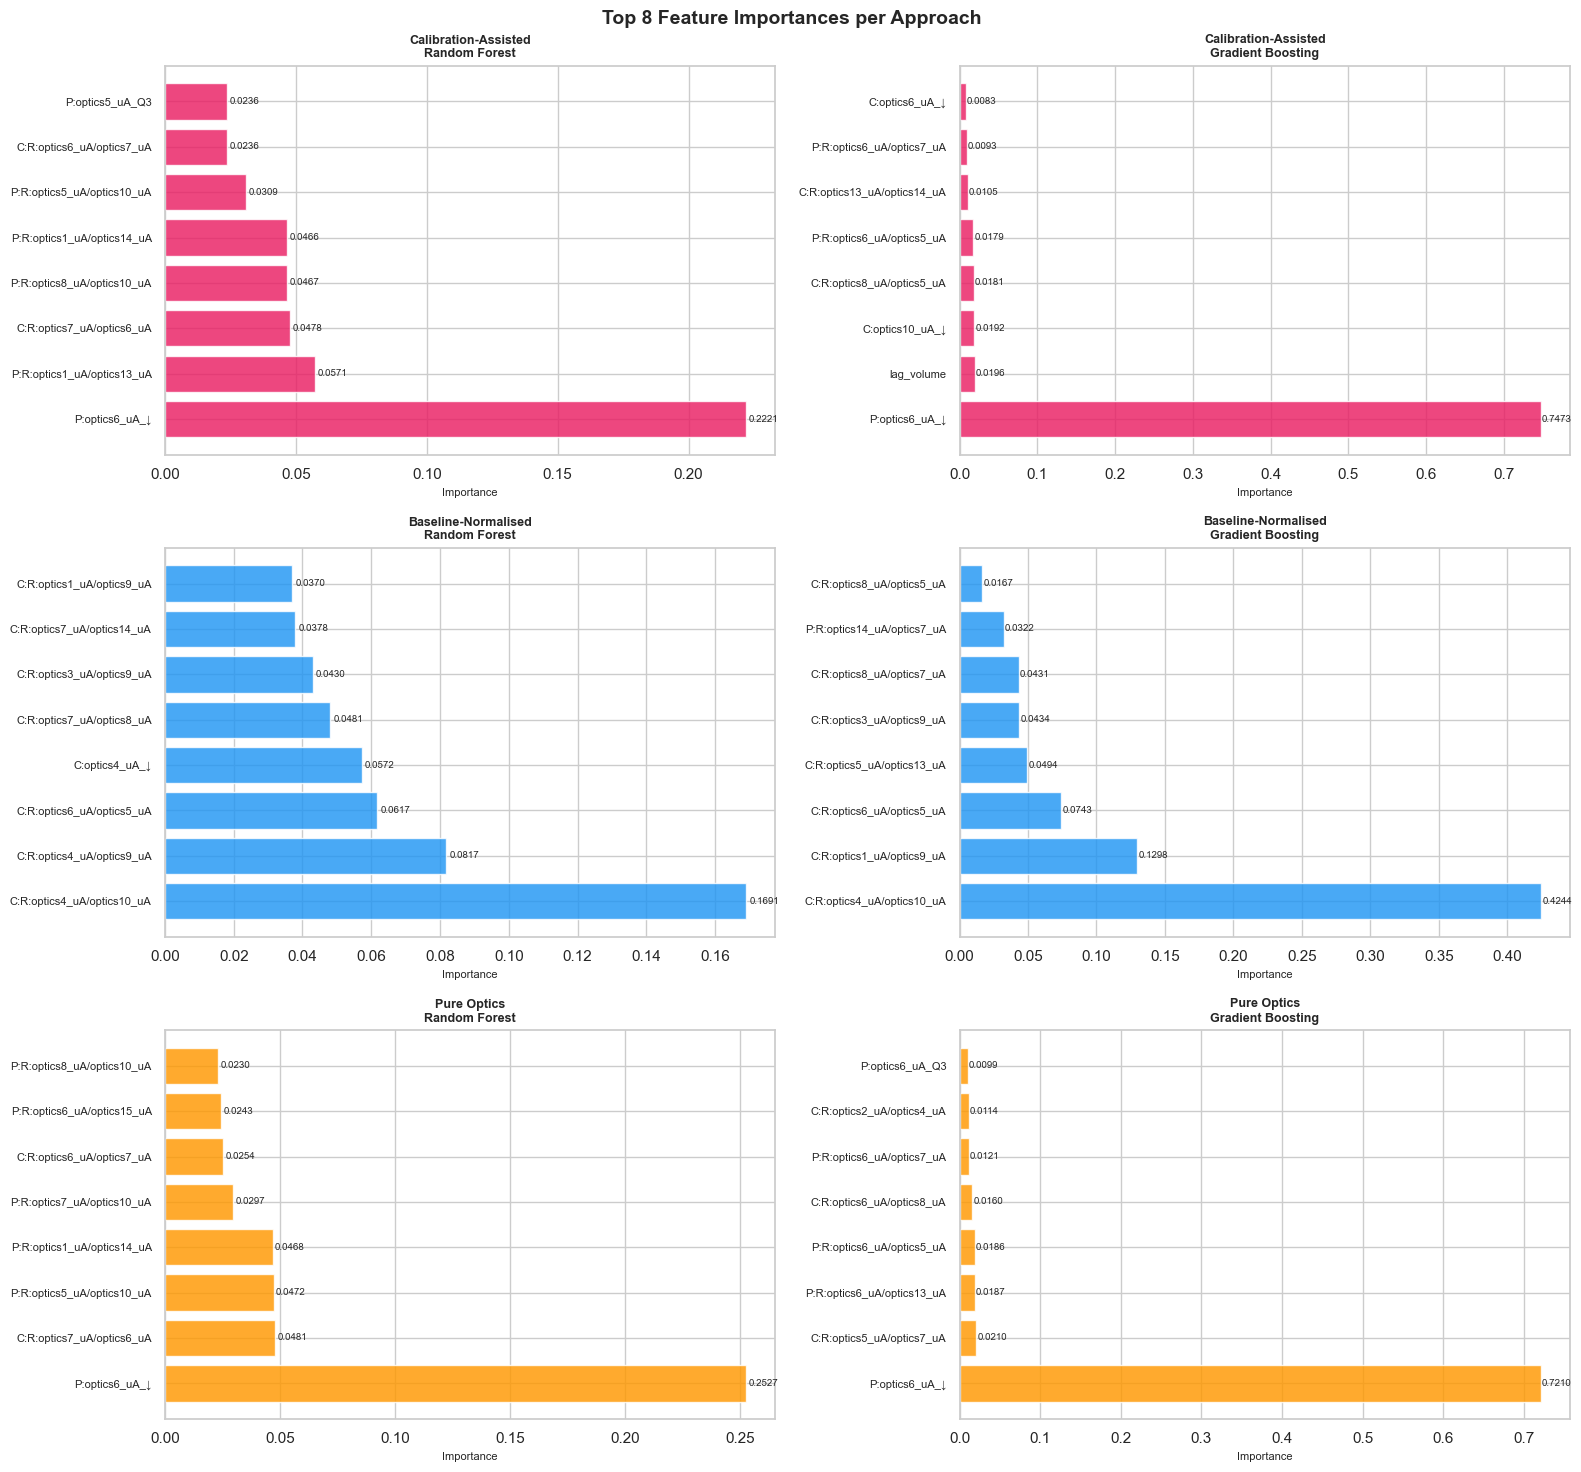

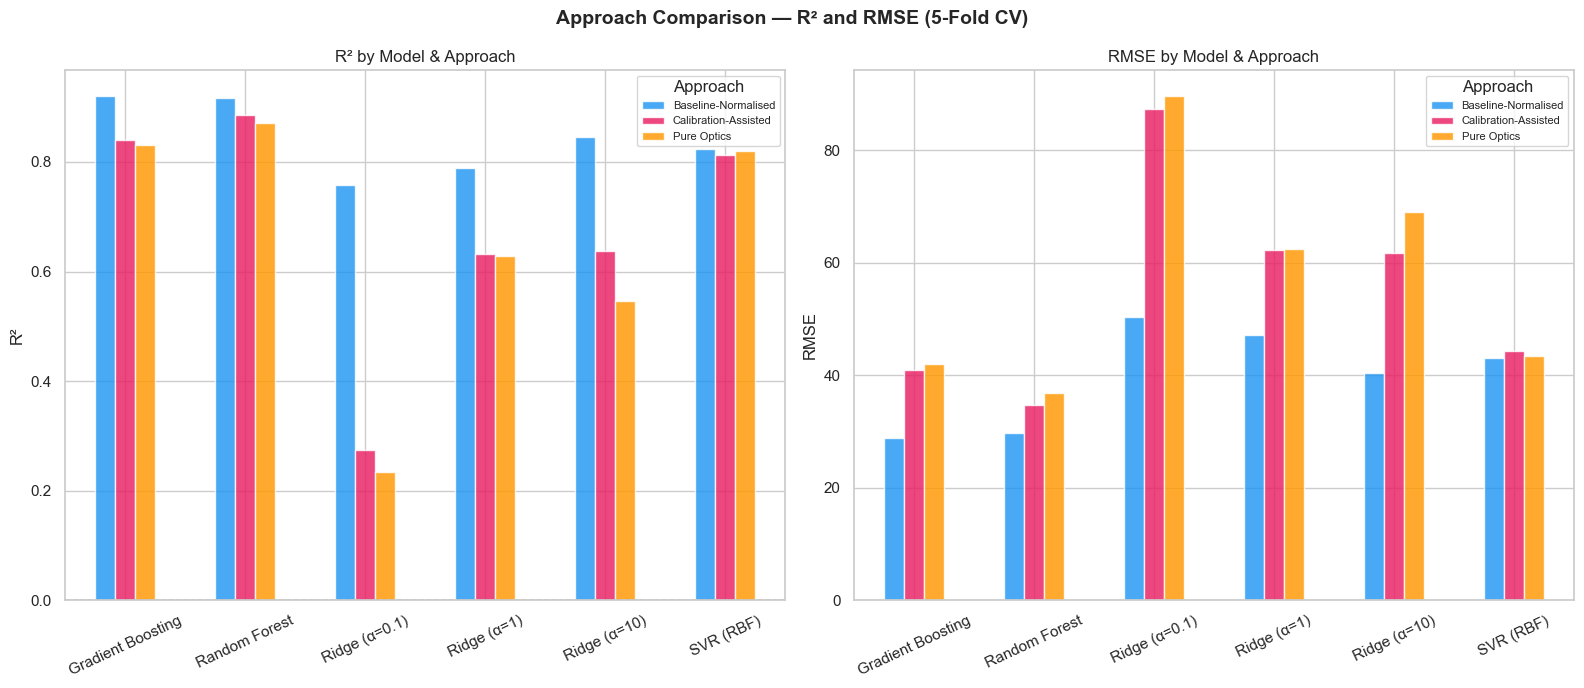

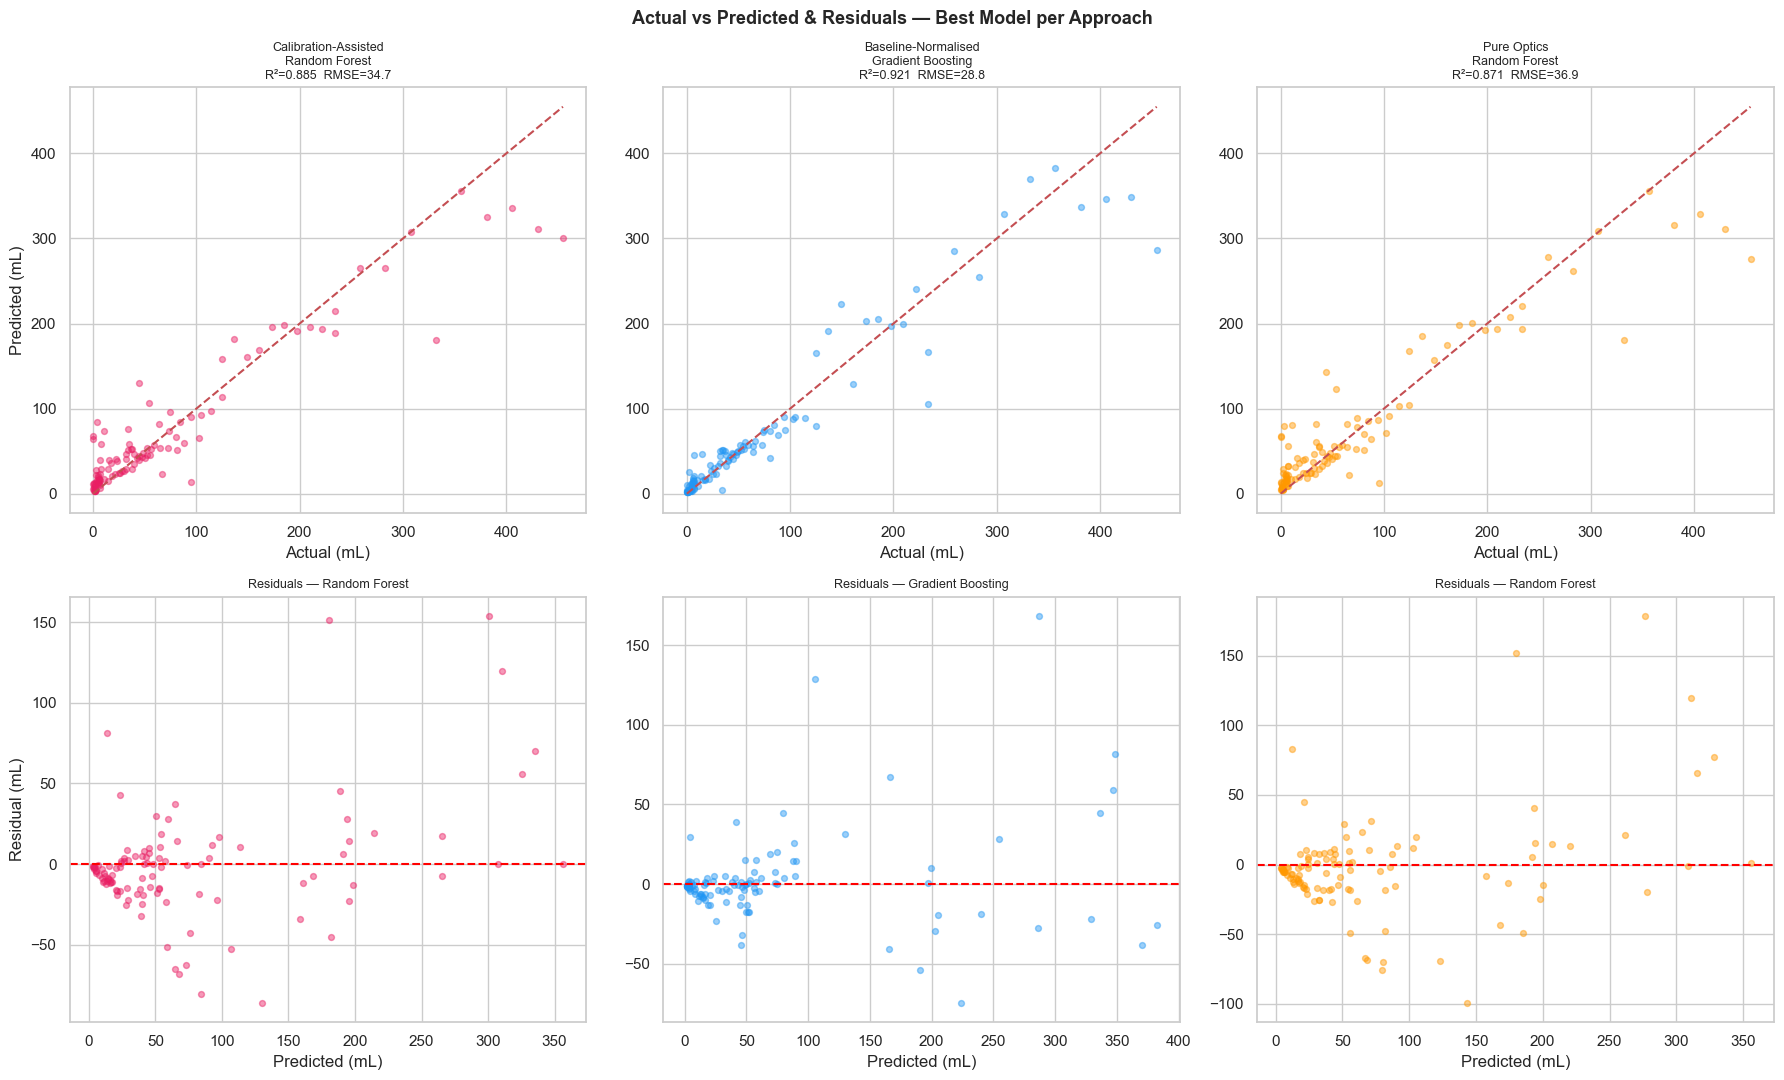

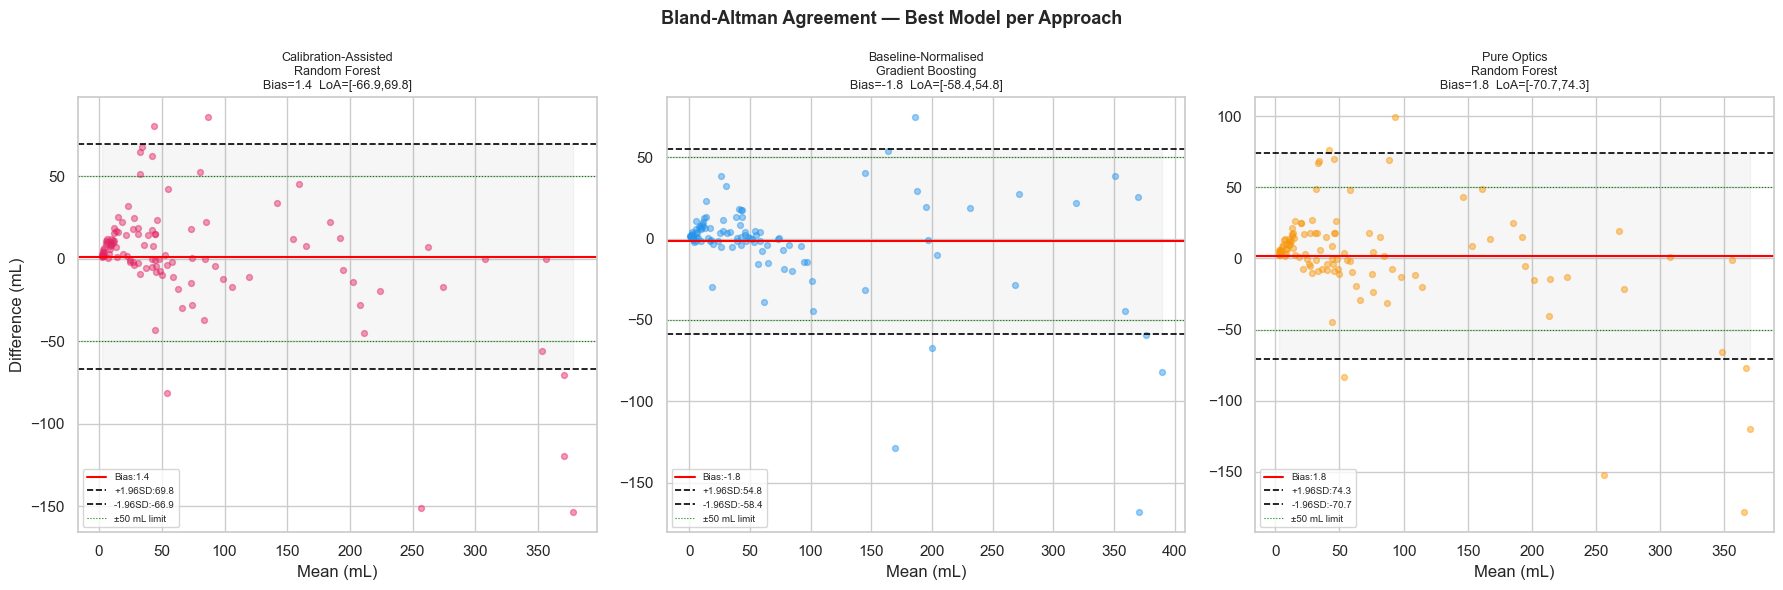

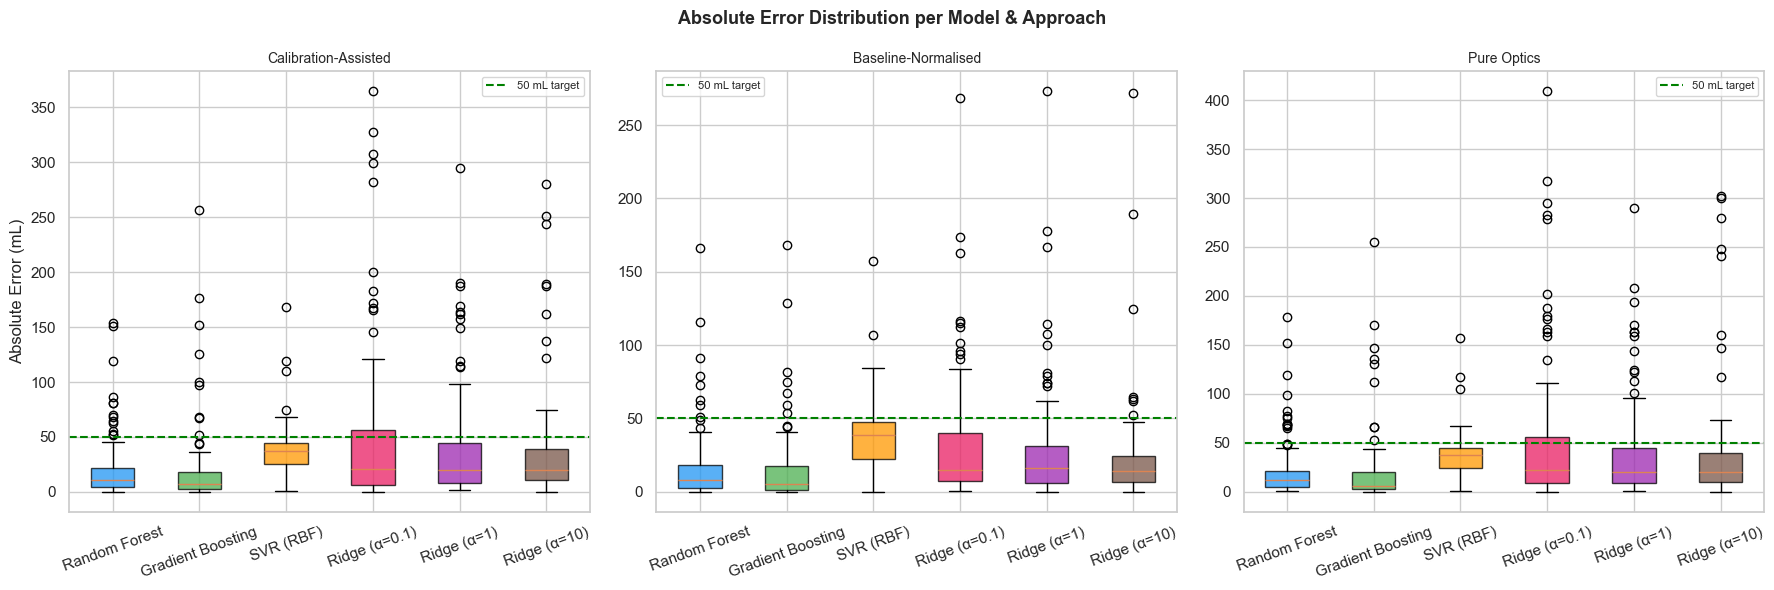

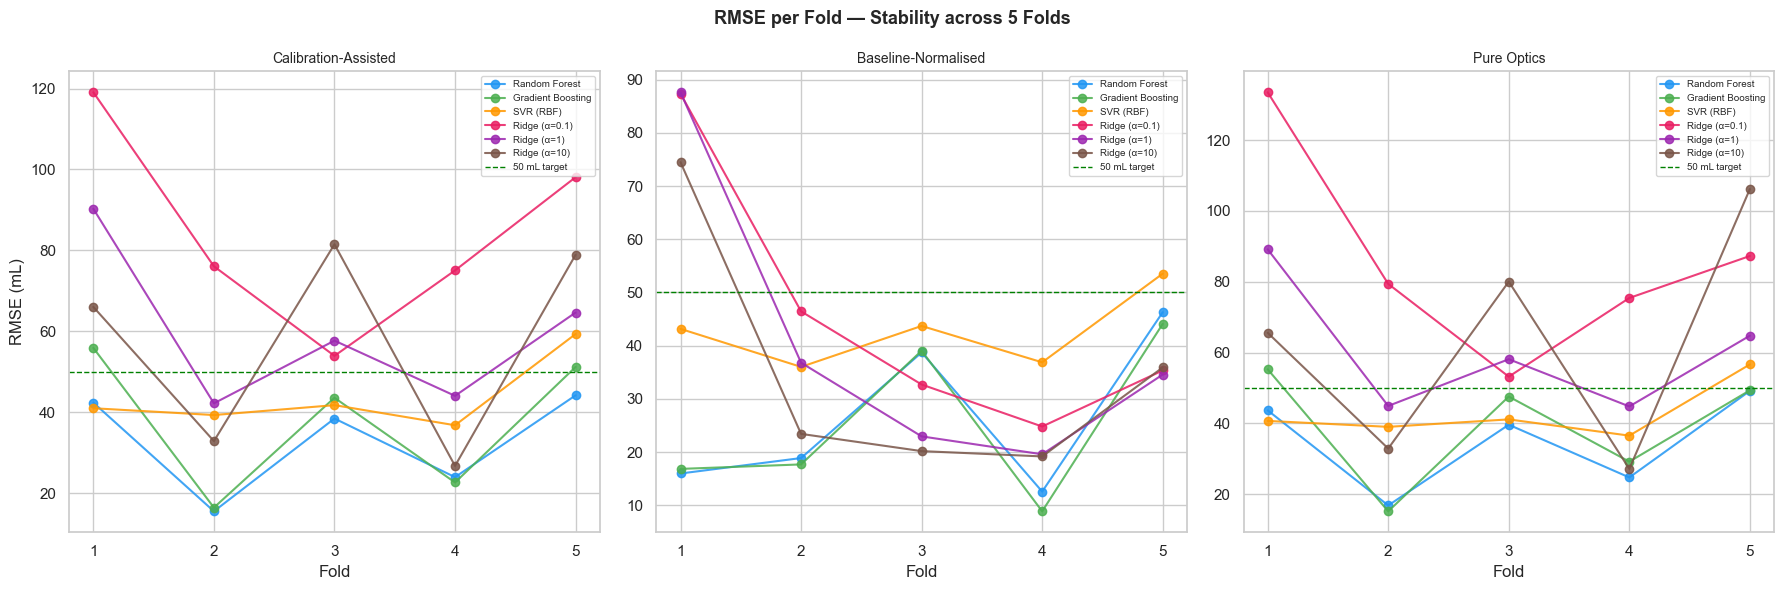

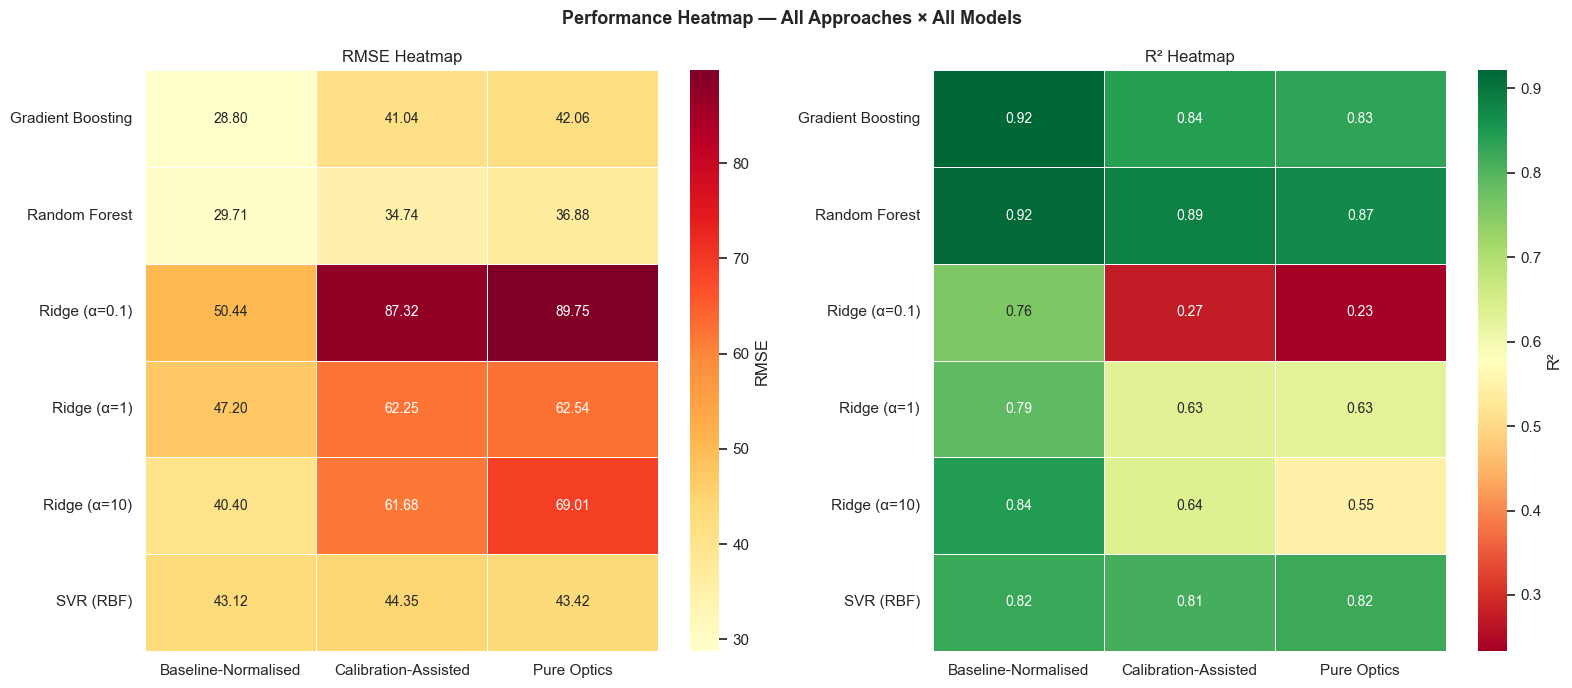

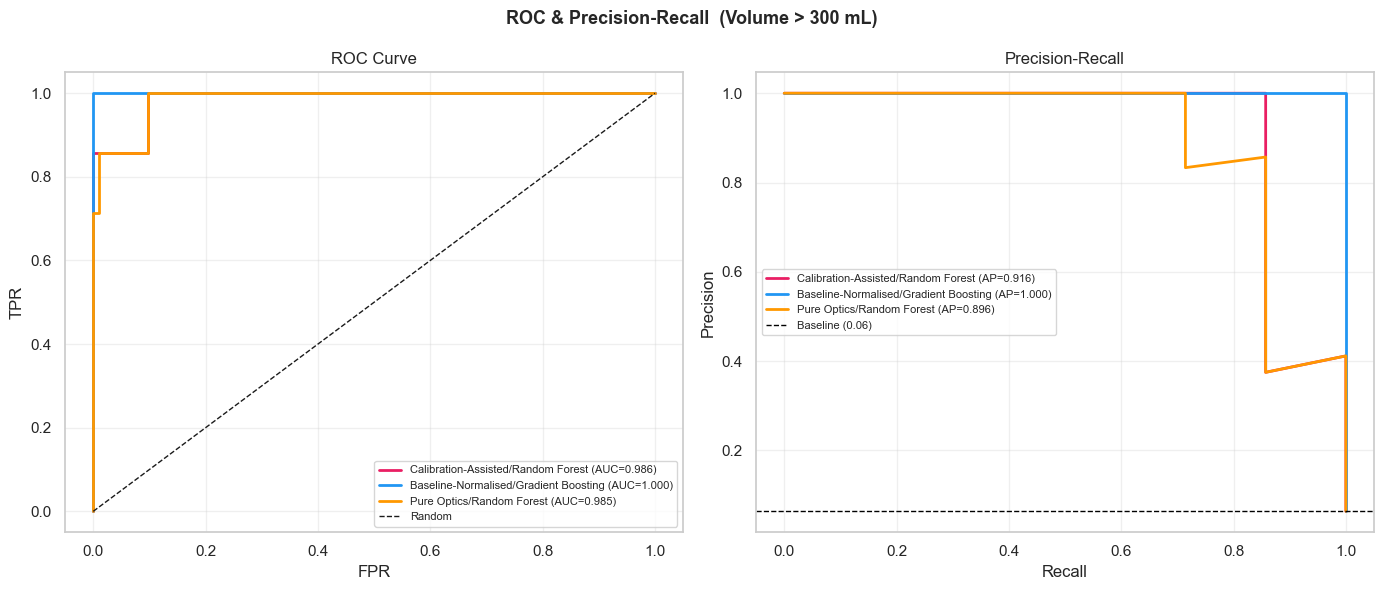


All figures saved: fig1–fig8


In [ ]:
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.linear_model import Ridge

warnings.filterwarnings('ignore')

# ── Constants ─────────────────────────────────────────────────────────────────
VOLUME_MIN             = 0
VOLUME_MAX             = 600
BLADDER_FULL_THRESHOLD = 300
N_FOLDS                = 5
DATA_FOLDER            = 'Data_Split'
COLUMNS_DROP           = ['timestamp', 'label', 'Interpolated_Volume']
TOP_N_FEATURES         = 8

approach_colors = {
    "Calibration-Assisted": "#E91E63",
    "Baseline-Normalised":  "#2196F3",
    "Pure Optics":          "#FF9800",
}
model_colors = {
    "Random Forest":     "#2196F3",
    "Gradient Boosting": "#4CAF50",
    "SVR (RBF)":         "#FF9800",
    "Ridge (α=0.1)":     "#E91E63",
    "Ridge (α=1)":       "#9C27B0",
    "Ridge (α=10)":      "#795548",
}

# ── 1. Load & clean metadata ──────────────────────────────────────────────────
df = pd.read_excel('Y_expanded.xlsx')
df = df[df['Patient.ID'] != 4].reset_index(drop=True)

before = len(df)
df = df[~((df['Patient.ID'] == 6) & (df['CSV_source'] == 'CSV3'))].reset_index(drop=True)
print(f"Removed {before - len(df)} rows (Patient 6 / CSV3)")

df['Volume'] = (
    df['Volume']
    .mask(~df['Volume'].between(VOLUME_MIN, VOLUME_MAX))
    .groupby(df['Patient.ID'])
    .transform(lambda s: s.ffill().bfill())
)
print(f"Volume range: [{df['Volume'].min():.2f}, {df['Volume'].max():.2f}]")
print(f"Samples per patient:\n{df.groupby('Patient.ID').size()}\n")

# ── 2. Feature extraction ─────────────────────────────────────────────────────
def extract_features(csv_path):
    csv_data = pd.read_csv(csv_path)
    csv_data = csv_data.drop(columns=[c for c in COLUMNS_DROP if c in csv_data.columns], errors='ignore')
    numeric_data = csv_data.select_dtypes(include=[np.number])
    if numeric_data.empty:
        return None, None
    cols    = numeric_data.columns.tolist()
    row_sum = numeric_data.sum(axis=1).replace(0, 1)
    norm    = numeric_data.div(row_sum, axis=0)
    features   = []
    feat_names = []
    col_means  = {}
    for col in cols:
        v = norm[col]; m = v.mean(); col_means[col] = m
        features.extend([m, v.std(), v.max(), v.min(), v.quantile(0.25), v.quantile(0.75)])
        feat_names.extend([f"{col}_mean", f"{col}_std", f"{col}_max",
                           f"{col}_min", f"{col}_q25", f"{col}_q75"])
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            m1, m2 = col_means[cols[i]], col_means[cols[j]]
            features.append(m1/m2 if (m2 != 0 and not np.isnan(m2)) else 0)
            features.append(m2/m1 if (m1 != 0 and not np.isnan(m1)) else 0)
            feat_names.append(f"ratio_{cols[i]}/{cols[j]}")
            feat_names.append(f"ratio_{cols[j]}/{cols[i]}")
    feat_arr = np.array([0 if (np.isnan(x) or np.isinf(x)) else x for x in features])
    return feat_arr, feat_names

# ── 3. Build raw records ──────────────────────────────────────────────────────
print("Extracting features...")
raw_records  = []
base_feat_names = None

for (pid, csv_src), group in df.groupby(['Patient.ID', 'CSV_source']):
    group = group.sort_values('Part').reset_index(drop=True)
    for _, row in group.iterrows():
        filepath = os.path.join(DATA_FOLDER, row['Filename'])
        if not os.path.exists(filepath):
            continue
        feat, fnames = extract_features(filepath)
        if feat is None:
            continue
        if base_feat_names is None:
            base_feat_names = fnames
        raw_records.append({
            'pid':    pid,
            'part':   row['Part'],
            'feat':   feat,
            'volume': row['Volume'],
        })

n_base = len(base_feat_names)
print(f"Total raw records : {len(raw_records)}")
print(f"Base features/part: {n_base}")

# ── 4. Prediction sanity filter ───────────────────────────────────────────────
def clean_predictions(y_pred, y_train_mean):
    s = pd.Series(y_pred.astype(float))
    s_clean = s.mask(~s.between(VOLUME_MIN, VOLUME_MAX)).ffill().bfill()
    return s_clean.fillna(y_train_mean).to_numpy(dtype=np.float64)

# ── 5. Feature matrix builders ────────────────────────────────────────────────
def build_matrices(approach):
    """
    approach:
      'calib'    — curr + prev optics + lag_volume
      'baseline' — (curr-base) + (prev-base) optics + lag_volume
      'pure'     — curr + prev optics ONLY (no volume information)
    """
    all_X, all_y, all_lag, all_pid = [], [], [], []
    rec_df = pd.DataFrame(raw_records)

    for pid, grp in rec_df.groupby('pid'):
        grp     = grp.sort_values('part').reset_index(drop=True)
        records = grp.to_dict('records')
        baseline_feat = records[0]['feat']

        for i, rec in enumerate(records):
            curr_feat = rec['feat']
            curr_vol  = rec['volume']
            prev_feat = records[i-1]['feat']   if i > 0 else np.zeros_like(curr_feat)
            prev_vol  = records[i-1]['volume'] if i > 0 else 0.0

            if approach == 'calib':
                X_row = np.concatenate([curr_feat, prev_feat, [prev_vol]])
            elif approach == 'baseline':
                X_row = np.concatenate([curr_feat - baseline_feat,
                                        prev_feat - baseline_feat, [prev_vol]])
            elif approach == 'pure':
                X_row = np.concatenate([curr_feat, prev_feat])   # NO lag volume

            all_X.append(X_row)
            all_y.append(curr_vol)
            all_lag.append(prev_vol)
            all_pid.append(pid)

    X = np.nan_to_num(np.array(all_X, dtype=np.float64), nan=0.0, posinf=0.0, neginf=0.0)
    y = np.array(all_y,  dtype=np.float64)
    l = np.array(all_lag, dtype=np.float64)
    p = np.array(all_pid)
    return X, y, l, p

def get_feature_names(approach):
    curr_names = [f"curr_{n}" for n in base_feat_names]
    prev_names = [f"prev_{n}" for n in base_feat_names]
    if approach in ('calib', 'baseline'):
        return curr_names + prev_names + ['lag_volume']
    else:  # pure
        return curr_names + prev_names

# ── 6. Models factory ─────────────────────────────────────────────────────────
def get_models():
    return {
        "Random Forest":     RandomForestRegressor(n_estimators=100, max_depth=6,
                                                   min_samples_split=4, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.05,
                                                       max_depth=3, random_state=42),
        "SVR (RBF)":         SVR(kernel='rbf', C=10, epsilon=0.1),
        "Ridge (α=0.1)":     Ridge(alpha=0.1),
        "Ridge (α=1)":       Ridge(alpha=1.0),
        "Ridge (α=10)":      Ridge(alpha=10.0),
    }

# ── 7. 5-Fold CV runner ───────────────────────────────────────────────────────
def run_kfold_cv(X, y, lag_vols, approach_name):
    kf      = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    models  = get_models()
    results = {name: {'y_true': [], 'y_pred': [], 'fold_rmse': []} for name in models}
    # Store last-fold trained models + scaled data for feature importance
    last_fold_models   = {}
    last_fold_X_train  = None
    last_fold_y_train  = None
    last_fold_X_test   = None
    last_fold_y_test   = None
    last_scaler_x      = None

    print(f"\n{'='*60}\n  Approach: {approach_name}  ({N_FOLDS}-Fold CV)\n{'='*60}")

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        lag_test        = lag_vols[test_idx]

        y_train_mean = float(np.nanmean(y_train))
        y_train = np.where(np.isnan(y_train), y_train_mean, y_train)
        y_test  = np.where(np.isnan(y_test),  y_train_mean, y_test)

        x_sc       = StandardScaler()
        X_train_sc = x_sc.fit_transform(X_train)
        X_test_sc  = x_sc.transform(X_test)

        y_sc       = MinMaxScaler()
        y_train_sc = y_sc.fit_transform(y_train.reshape(-1,1)).ravel()

        fold_models = {}
        for name, model in models.items():
            model.fit(X_train_sc, y_train_sc)
            y_pred    = y_sc.inverse_transform(
                np.clip(model.predict(X_test_sc), -10, 10).reshape(-1,1)
            ).ravel()
            y_pred    = clean_predictions(y_pred, y_train_mean)
            y_pred    = np.where(np.isnan(y_pred), y_train_mean, y_pred)

            results[name]['y_true'].extend(y_test.tolist())
            results[name]['y_pred'].extend(y_pred.tolist())
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            results[name]['fold_rmse'].append(rmse)
            fold_models[name] = model

        # Save last fold for feature importance
        if fold == N_FOLDS - 1:
            last_fold_models  = fold_models
            last_fold_X_train = X_train_sc
            last_fold_y_train = y_train
            last_fold_X_test  = X_test_sc
            last_fold_y_test  = y_test
            last_scaler_x     = x_sc

    # Print summary
    print(f"\n  {'Model':20s}  {'RMSE':>8}  {'MAE':>8}  {'R²':>8}")
    for name, res in results.items():
        yt = np.array(res['y_true']); yp = np.array(res['y_pred'])
        print(f"  {name:20s}  {np.sqrt(mean_squared_error(yt,yp)):8.2f}  "
              f"{mean_absolute_error(yt,yp):8.2f}  {r2_score(yt,yp):8.3f}")

    results['_meta'] = {
        'last_fold_models':  last_fold_models,
        'last_fold_X_train': last_fold_X_train,
        'last_fold_y_train': last_fold_y_train,
        'last_fold_X_test':  last_fold_X_test,
        'last_fold_y_test':  last_fold_y_test,
        'last_scaler_x':     last_scaler_x,
    }
    return results

# ── 8. Run all 3 approaches ───────────────────────────────────────────────────
X_c, y_c, l_c, p_c = build_matrices('calib')
X_b, y_b, l_b, p_b = build_matrices('baseline')
X_p, y_p, l_p, p_p = build_matrices('pure')

res_calib    = run_kfold_cv(X_c, y_c, l_c, "Calibration-Assisted")
res_baseline = run_kfold_cv(X_b, y_b, l_b, "Baseline-Normalised")
res_pure     = run_kfold_cv(X_p, y_p, l_p, "Pure Optics")

all_approaches = {
    "Calibration-Assisted": (res_calib,    X_c),
    "Baseline-Normalised":  (res_baseline, X_b),
    "Pure Optics":          (res_pure,     X_p),
}

# ── 9. Summary table ──────────────────────────────────────────────────────────
print("\n\n=== FULL SUMMARY (5-Fold CV) ===")
summary_rows = []
for approach, (res_dict, _) in all_approaches.items():
    for model_name, res in res_dict.items():
        if model_name == '_meta': continue
        yt   = np.array(res['y_true']); yp = np.array(res['y_pred'])
        frmse = np.array(res['fold_rmse'])
        summary_rows.append({
            'Approach':  approach,
            'Model':     model_name,
            'RMSE':      np.sqrt(mean_squared_error(yt, yp)),
            'MAE':       mean_absolute_error(yt, yp),
            'R²':        r2_score(yt, yp),
            'RMSE_std':  frmse.std(),
        })

summary_df = pd.DataFrame(summary_rows).sort_values('R²', ascending=False)
print(summary_df.to_string(index=False))
best_row      = summary_df.iloc[0]
best_approach = best_row['Approach']
best_model    = best_row['Model']
print(f"\n★ Best: [{best_approach}] {best_model}  "
      f"R²={best_row['R²']:.4f}  RMSE={best_row['RMSE']:.2f} ± {best_row['RMSE_std']:.2f} mL")

# ─────────────────────────────────────────────────────────────────────────────
# HELPER
# ─────────────────────────────────────────────────────────────────────────────
def best_in_approach(res_dict):
    return max([k for k in res_dict if k != '_meta'],
               key=lambda n: r2_score(np.array(res_dict[n]['y_true']),
                                      np.array(res_dict[n]['y_pred'])))

def bland_altman_stats(yt, yp):
    diff = yp - yt; means = (yp+yt)/2; bias = np.mean(diff); sd = np.std(diff, ddof=1)
    return means, diff, bias, sd, bias-1.96*sd, bias+1.96*sd

sns.set_theme(style="whitegrid")

# ─────────────────────────────────────────────────────────────────────────────
# FIG 1 — Feature Importances (Top 8 per approach, RF + GB)
# ─────────────────────────────────────────────────────────────────────────────
approach_keys = ['calib', 'baseline', 'pure']
approach_labels = list(all_approaches.keys())
imp_models = ["Random Forest", "Gradient Boosting"]

fig1, axes1 = plt.subplots(len(approach_labels), len(imp_models),
                            figsize=(16, 5 * len(approach_labels)))
fig1.suptitle(f'Top {TOP_N_FEATURES} Feature Importances per Approach', fontsize=14, fontweight='bold')

for row_idx, (approach, (res_dict, X_mat)) in enumerate(all_approaches.items()):
    app_key  = approach_keys[row_idx]
    feat_names = get_feature_names(app_key)
    meta       = res_dict['_meta']

    for col_idx, mname in enumerate(imp_models):
        ax    = axes1[row_idx, col_idx]
        model = meta['last_fold_models'][mname]

        # Tree-based models have native feature_importances_
        importances = model.feature_importances_
        indices     = np.argsort(importances)[::-1][:TOP_N_FEATURES]
        top_imp     = importances[indices]
        top_names   = [feat_names[i] if i < len(feat_names) else f"feat_{i}"
                       for i in indices]
        # Shorten names for display
        top_names_short = [n.replace('curr_', 'C:').replace('prev_', 'P:')
                            .replace('ratio_', 'R:').replace('_mean','_μ')
                            .replace('_std','_σ').replace('_max','_↑')
                            .replace('_min','_↓').replace('_q25','_Q1')
                            .replace('_q75','_Q3')
                           for n in top_names]
        colors = [approach_colors[approach]] * len(top_imp)
        bars   = ax.barh(range(len(top_imp))[::-1], top_imp, color=colors, alpha=0.82, edgecolor='white')
        ax.set_yticks(range(len(top_imp))[::-1])
        ax.set_yticklabels(top_names_short, fontsize=8)
        ax.set_xlabel('Importance', fontsize=8)
        ax.set_title(f'{approach}\n{mname}', fontsize=9, fontweight='bold')
        ax.invert_yaxis()
        # Annotate bars
        for bar, val in zip(bars, top_imp):
            ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('fig1_feature_importances.png', dpi=150, bbox_inches='tight'); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIG 2 — R² & RMSE comparison bar chart
# ─────────────────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 7))
fig2.suptitle('Approach Comparison — R² and RMSE (5-Fold CV)', fontsize=14, fontweight='bold')
for ax, metric in zip(axes2, ['R²', 'RMSE']):
    pivot = summary_df.pivot_table(index='Model', columns='Approach', values=metric, aggfunc='mean')
    pivot.plot(kind='bar', ax=ax,
               color=[approach_colors[c] for c in pivot.columns], alpha=0.82, edgecolor='white')
    ax.set_title(f'{metric} by Model & Approach')
    ax.set_ylabel(metric); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    if metric == 'R²': ax.axhline(0, color='black', lw=1, linestyle='--')
    ax.legend(title='Approach', fontsize=8)
plt.tight_layout()
plt.savefig('fig2_approach_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIG 3 — Actual vs Predicted + Residuals (best model per approach)
# ─────────────────────────────────────────────────────────────────────────────
fig3, axes3 = plt.subplots(2, 3, figsize=(18, 11))
fig3.suptitle('Actual vs Predicted & Residuals — Best Model per Approach', fontsize=13, fontweight='bold')

for idx, (approach, (res_dict, _)) in enumerate(all_approaches.items()):
    name  = best_in_approach(res_dict)
    res   = res_dict[name]
    yt    = np.array(res['y_true']); yp = np.array(res['y_pred'])
    r2    = r2_score(yt, yp); rmse = np.sqrt(mean_squared_error(yt, yp))
    color = approach_colors[approach]

    # Actual vs Predicted
    ax = axes3[0, idx]
    ax.scatter(yt, yp, alpha=0.45, s=18, color=color)
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', lw=1.5)
    ax.set_title(f'{approach}\n{name}\nR²={r2:.3f}  RMSE={rmse:.1f}', fontsize=9)
    ax.set_xlabel('Actual (mL)'); ax.set_ylabel('Predicted (mL)' if idx==0 else '')

    # Residuals
    ax2 = axes3[1, idx]
    ax2.scatter(yp, yt-yp, alpha=0.45, s=18, color=color)
    ax2.axhline(0, color='red', lw=1.5, linestyle='--')
    ax2.set_title(f'Residuals — {name}', fontsize=9)
    ax2.set_xlabel('Predicted (mL)'); ax2.set_ylabel('Residual (mL)' if idx==0 else '')

plt.tight_layout()
plt.savefig('fig3_actual_vs_predicted.png', dpi=150, bbox_inches='tight'); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIG 4 — Bland-Altman (best model per approach)
# ─────────────────────────────────────────────────────────────────────────────
fig4, axes4 = plt.subplots(1, 3, figsize=(18, 6))
fig4.suptitle('Bland-Altman Agreement — Best Model per Approach', fontsize=13, fontweight='bold')

for idx, (approach, (res_dict, _)) in enumerate(all_approaches.items()):
    name  = best_in_approach(res_dict)
    res   = res_dict[name]
    yt    = np.array(res['y_true']); yp = np.array(res['y_pred'])
    color = approach_colors[approach]
    means, diff, bias, sd, loa_lo, loa_hi = bland_altman_stats(yt, yp)
    ax    = axes4[idx]
    ax.scatter(means, diff, alpha=0.45, s=18, color=color)
    ax.axhline(bias,   color='red',   lw=1.5, linestyle='-',  label=f'Bias:{bias:.1f}')
    ax.axhline(loa_hi, color='black', lw=1.2, linestyle='--', label=f'+1.96SD:{loa_hi:.1f}')
    ax.axhline(loa_lo, color='black', lw=1.2, linestyle='--', label=f'-1.96SD:{loa_lo:.1f}')
    ax.axhline( 50,    color='green', lw=0.8, linestyle=':')
    ax.axhline(-50,    color='green', lw=0.8, linestyle=':', label='±50 mL limit')
    ax.fill_between([means.min(), means.max()], loa_lo, loa_hi, alpha=0.07, color='gray')
    ax.set_title(f'{approach}\n{name}\nBias={bias:.1f}  LoA=[{loa_lo:.1f},{loa_hi:.1f}]', fontsize=9)
    ax.set_xlabel('Mean (mL)'); ax.set_ylabel('Difference (mL)' if idx==0 else '')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('fig4_bland_altman.png', dpi=150, bbox_inches='tight'); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIG 5 — Error Boxplot per approach
# ─────────────────────────────────────────────────────────────────────────────
fig5, axes5 = plt.subplots(1, 3, figsize=(18, 6))
fig5.suptitle('Absolute Error Distribution per Model & Approach', fontsize=13, fontweight='bold')
for idx, (approach, (res_dict, _)) in enumerate(all_approaches.items()):
    ax = axes5[idx]
    err_data, err_labels = [], []
    for name, res in res_dict.items():
        if name == '_meta': continue
        yt = np.array(res['y_true']); yp = np.array(res['y_pred'])
        err_data.append(np.abs(yt - yp)); err_labels.append(name)
    bp = ax.boxplot(err_data, labels=err_labels, patch_artist=True)
    for patch, nm in zip(bp['boxes'], [k for k in res_dict if k != '_meta']):
        patch.set_facecolor(model_colors.get(nm, 'steelblue')); patch.set_alpha(0.75)
    ax.axhline(50, color='green', linestyle='--', lw=1.5, label='50 mL target')
    ax.set_title(approach, fontsize=10)
    ax.set_ylabel('Absolute Error (mL)' if idx==0 else '')
    ax.tick_params(axis='x', rotation=20); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig5_error_boxplot.png', dpi=150, bbox_inches='tight'); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIG 6 — Fold RMSE stability
# ─────────────────────────────────────────────────────────────────────────────
fig6, axes6 = plt.subplots(1, 3, figsize=(18, 6))
fig6.suptitle(f'RMSE per Fold — Stability across {N_FOLDS} Folds', fontsize=13, fontweight='bold')
for idx, (approach, (res_dict, _)) in enumerate(all_approaches.items()):
    ax = axes6[idx]
    for name, res in res_dict.items():
        if name == '_meta': continue
        ax.plot(range(1, N_FOLDS+1), res['fold_rmse'], marker='o', lw=1.5,
                color=model_colors.get(name, 'gray'), label=name, alpha=0.85)
    ax.set_title(approach, fontsize=10)
    ax.set_xlabel('Fold'); ax.set_ylabel('RMSE (mL)' if idx==0 else '')
    ax.set_xticks(range(1, N_FOLDS+1))
    ax.axhline(50, color='green', linestyle='--', lw=1, label='50 mL target')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('fig6_fold_stability.png', dpi=150, bbox_inches='tight'); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIG 7 — Performance heatmap R² & RMSE
# ─────────────────────────────────────────────────────────────────────────────
fig7, axes7 = plt.subplots(1, 2, figsize=(16, 7))
fig7.suptitle('Performance Heatmap — All Approaches × All Models', fontsize=13, fontweight='bold')
for ax, metric in zip(axes7, ['RMSE', 'R²']):
    piv  = summary_df.pivot_table(index='Model', columns='Approach', values=metric, aggfunc='mean')
    cmap = 'YlOrRd' if metric == 'RMSE' else 'RdYlGn'
    sns.heatmap(piv, annot=True, fmt='.2f', cmap=cmap, ax=ax,
                linewidths=0.5, annot_kws={'size': 10}, cbar_kws={'label': metric})
    ax.set_title(f'{metric} Heatmap'); ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('fig7_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
